<a href="https://colab.research.google.com/github/PixelPusher8386/PythonPrograms/blob/main/%5BWS5%5DComputer_Vision_Pneunomia.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Welcome! In this hands‑on session, we’ll go from **zero to a working chest X‑ray classifier**.  





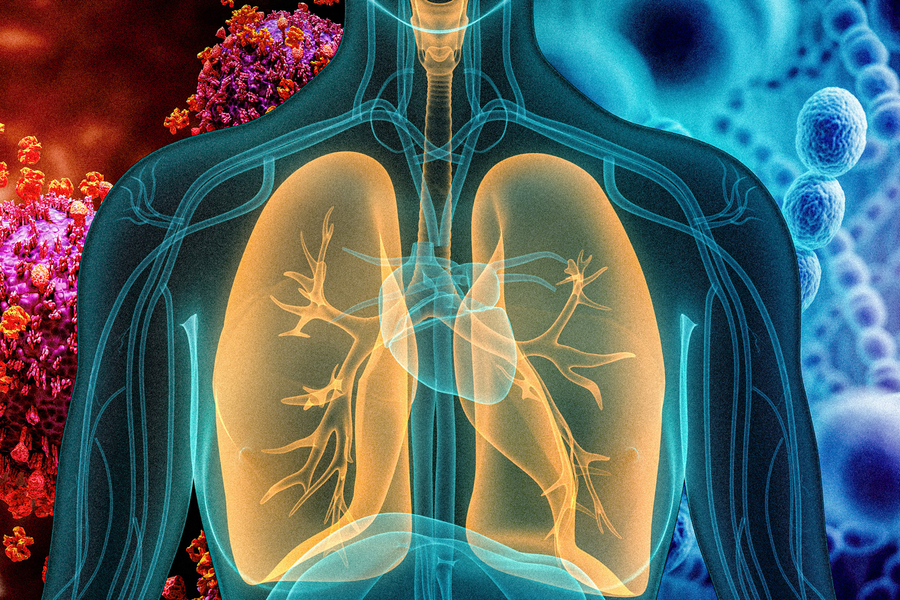

##What is the pneumonia?

Pneumonia is an infection that inflames the air sacs in one or both lungs. The air sacs may fill with fluid or pus, causing cough with phlegm or pus, fever, chills, and difficulty breathing.

##Risk factors

Bacteria in the bloodstream (bacteremia)

Difficulty breathing

Fluid accumulation around the lungs (pleural effusion)

Lung abscess





##⚙️Step 0 - Dependencies Installation

We install and verify all required libraries so every participant can run the notebook smoothly. This keeps everyone on the same page before training starts.

**Why it matters:** *This step plugs into the end‑to‑end CV pipeline you’ll reuse in your own projects.* ✨


In [ ]:
!pip install -q torch torchvision torchaudio
!pip install -q scikit-learn matplotlib tqdm


##📦Step 1 -  Get the Dataset from Kaggle

We pull the Chest X-ray dataset directly from Kaggle.




In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


## ⚙️ Step 2 — Imports & Environment Setup  

Before we get into any deep learning magic 🪄, let’s make sure our environment is ready to roll.  
In this section, we’ll import all the essential libraries and set up a consistent, reproducible workspace.  

### 📦 What’s happening here  
- Import core Python utilities (`os`, `glob`, `random`, `tqdm`) for file handling and progress bars 🧰  
- Load **PyTorch** and **Torchvision** for model building, data handling, and training 🔥  
- Pull in **ResNet50** — a classic convolutional neural network pre-trained on ImageNet 🧠  
- Include **scikit-learn** tools for evaluation metrics (accuracy, F1, AUC, etc.) 📊  
- Initialize a **random seed** and **device setup** so results are stable and GPU-ready ⚙️  

### 🌟 Why it matters  
Setting up your environment carefully ensures your experiments are **reproducible**, **deterministic**, and **ready for scaling** — all marks of a professional deep learning workflow.

> 💡 *“Good code hygiene makes great models.”*



In [ ]:
# =========================
# Block 1 — Imports & Setup
# =========================
import os, shutil, random, numpy as np
from glob import glob
from tqdm import tqdm

import torch
import torch.nn as nn


import itertools
from pathlib import Path

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


DATA_ROOT = os.path.join(path, "chest_xray")
TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")
CLASSES   = ["NORMAL", "PNEUMONIA"]

## 👀 Step 3 — Visualizing the Dataset  

Before diving into training, let’s take a quick *look* at our data — literally! 🩻  

In this block, we’ll **visualize how our dataset is structured** and **peek at a few random samples** to make sure everything looks healthy and balanced.

### 📊 What we’ll see
- A **bar chart** comparing the number of images in each split (`train`, `val`, `test`) for both classes — this helps us confirm our re-split worked correctly 🧮  
- A **gallery of sample chest X-rays** from the training set, showing both **NORMAL** and **PNEUMONIA** cases side by side 👩‍⚕️👨‍⚕️  

### 🧐 Why it matters
A quick visualization check can catch:
- Class imbalance ⚖️  
- Unexpected grayscale or color format issues 🌈  

> 💡 *“Always look at your data first.”*  
Even deep learning pros know: no model can fix bad data — but a good plot can reveal it early!


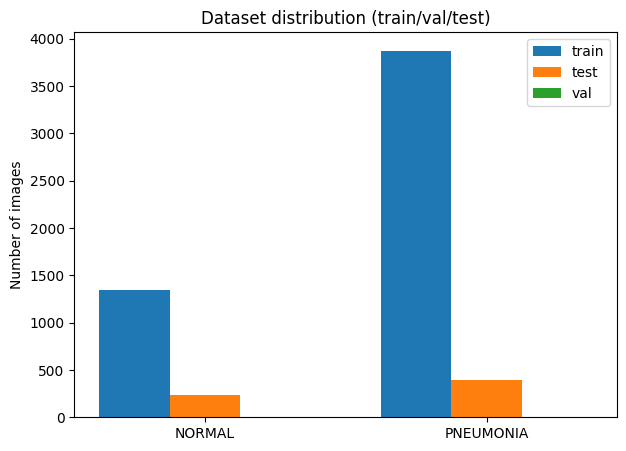

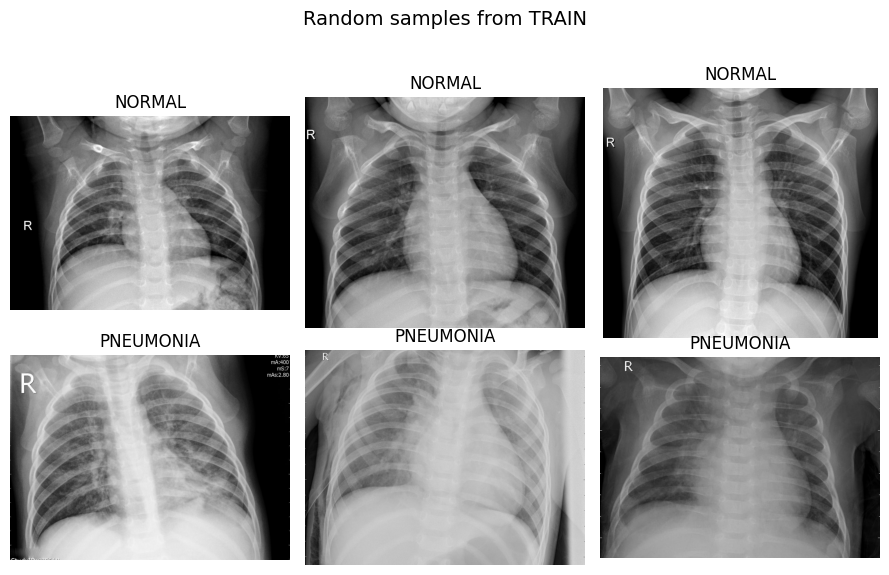

In [ ]:
# =========================
# Visualization Block — Simple Version
# =========================
import matplotlib.pyplot as plt
import random
from glob import glob
import os
from PIL import Image
import numpy as np

splits = ["train", "test", "val"] # Fixed typo: removed extra space from "test "
cls_counts = {split: {} for split in splits}


# ---- Count images per split/class ----
for split in splits:
    for c in CLASSES:
        split_dir = os.path.join(DATA_ROOT, split, c)
        n = len(glob(os.path.join(split_dir, "*")))
        #Update cls_counts at here
        cls_counts[split][c] = n # Added this line to populate cls_counts

# ---- Plot class distribution ----
fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(CLASSES))
bar_width = 0.25

for i, split in enumerate(splits):
    counts = [cls_counts[split][c] for c in CLASSES]
    ax.bar(x + i * bar_width, counts, width=bar_width, label=split)

ax.set_xticks(x + bar_width)
ax.set_xticklabels(CLASSES)
ax.set_ylabel("Number of images")
ax.set_title("Dataset distribution (train/val/test)")
ax.legend()
plt.show()

# ---- Show 3 random images per class from TRAIN ----
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
fig.suptitle("Random samples from TRAIN", fontsize=14)

for i, c in enumerate(CLASSES):
    img_paths = glob(os.path.join(DATA_ROOT, "train", c, "*"))
    sample_imgs = random.sample(img_paths, 3)
    for j, img_path in enumerate(sample_imgs):
        img = Image.open(img_path).convert("RGB")
        ax = axes[i, j]
        ax.imshow(img)
        ax.set_title(c)
        ax.axis("off")

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## 🗂️ Step 4 — Re-Splitting the Dataset (8 : 1 : 1)  

Before we start modeling, let’s fix one common issue with the original Kaggle dataset —  
the **data split is unbalanced** ⚠️: the validation set is too small compared to training, and some classes appear unevenly across splits.

To ensure fair learning and reliable evaluation, we’ll:
- Gather **all NORMAL and PNEUMONIA images** from the original Kaggle folders 📸  
- **Randomly reshuffle** and re-divide them into an **8 : 1 : 1** ratio → train : val : test 🔁  
- Save the new structure inside the writable directory `/kaggle/working/resplit_811`  

This way every subset has a healthy mix of both classes, keeping the model honest and the metrics meaningful 🩺  

> 💡 *A balanced split means a trustworthy evaluation — no cheating by data overlap!*


In [ ]:
# =========================
# Block 1 — Re-split 8:1:1 (Kaggle working dir)
# highly uneven dataset because most datappint is pneunomia positive
# =========================
import os, random, shutil
from glob import glob
from tqdm import tqdm

random.seed(42)

# Original Kaggle dataset (read-only)
SRC_ROOT = "/kaggle/input/chest-xray-pneumonia/chest_xray"
CLASSES  = ["NORMAL", "PNEUMONIA"]

# New balanced dataset will be created here (writable)
TARGET_ROOT = "/kaggle/working/resplit_811"
os.makedirs(TARGET_ROOT, exist_ok=True)

# Create destination subfolders
for split in ["train", "val", "test"]:
    for c in CLASSES:
        os.makedirs(os.path.join(TARGET_ROOT, split, c), exist_ok=True)

# Re-split each class independently to preserve class ratio
for c in CLASSES:
    imgs = []
    for s in ["train", "val", "test"]:
        imgs += glob(os.path.join(SRC_ROOT, s, c, "*"))
    random.shuffle(imgs)

    n = len(imgs)
    n_train, n_val = int(0.8 * n), int(0.1 * n)
    splits = {
        "train": imgs[:n_train],
        "val":   imgs[n_train:n_train + n_val],
        "test":  imgs[n_train + n_val:]
    }

    # Copy files into the new directory structure
    for split, files in splits.items():
        dst = os.path.join(TARGET_ROOT, split, c)
        for f in tqdm(files, desc=f"{c} → {split}", leave=False):
            shutil.copy2(f, os.path.join(dst, os.path.basename(f)))

print("✅ Re-split complete!")
print("📁 New dataset saved in:", TARGET_ROOT)

# Export paths for later use
TRAIN_DIR = os.path.join(TARGET_ROOT, "train")
VAL_DIR   = os.path.join(TARGET_ROOT, "val")
TEST_DIR  = os.path.join(TARGET_ROOT, "test")

✅ Re-split complete!
📁 New dataset saved in: /kaggle/working/resplit_811


## 🧺 Step 5 — Building Our Dataset & Dataloaders  

In this section, we’ll transform raw chest X-ray images into a well-organized, PyTorch-friendly format.

### 🔧 What happens here
- Define **image transformations (augmentations)** like random crops and flips — these help the model *see beyond noise* and generalize better 🎨  
- Build **train, validation, and test** datasets using `ImageFolder`, keeping everything neatly labeled 📂  
- Wrap them in **DataLoaders** to feed the network efficiently in mini-batches 🚚  
- Compute **class weights** to balance the dataset ⚖️ — this ensures pneumonia and normal images contribute fairly to the loss



> 💡 *Good data beats clever models — every time.*


In [ ]:
# =========================================
# Block 2 — Datasets / Dataloaders / Weights
# =========================================
import torch
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

IM_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.RandomResizedCrop(IM_SIZE, scale=(0.85, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    #Normalize the image,
])
eval_tfms = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize(256),
    transforms.CenterCrop(IM_SIZE),
    transforms.ToTensor(),
    #Nromalize the image,
])

train_ds = ImageFolder(TRAIN_DIR, transform=train_tfms)
val_ds   = ImageFolder(VAL_DIR,   transform=eval_tfms)
test_ds  = ImageFolder(TEST_DIR,  transform=eval_tfms)

BATCH_SIZE = 32
NUM_WORKERS = 2 if device.type == "cuda" else 0

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=(device.type=="cuda"))

print("Classes:", train_ds.classes)

# class weight
import numpy as np
targets = np.array(train_ds.targets)
#[0, 0, 0, 1, 1, 0]
num_classes = len(train_ds.classes)
#2
counts = np.bincount(targets, minlength=num_classes)
#[4, 2]
freq = counts / counts.sum()
class_weights = 1.0 / np.clip(freq, 1e-6, None)
class_weights = class_weights / class_weights.mean()
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
print("Train counts:", dict(zip(train_ds.classes, counts.tolist())))
print("Class weights:", dict(zip(train_ds.classes, class_weights.detach().cpu().numpy().round(4))))


Classes: ['NORMAL', 'PNEUMONIA']
Train counts: {'NORMAL': 1266, 'PNEUMONIA': 3418}
Class weights: {'NORMAL': np.float32(1.4594), 'PNEUMONIA': np.float32(0.5406)}



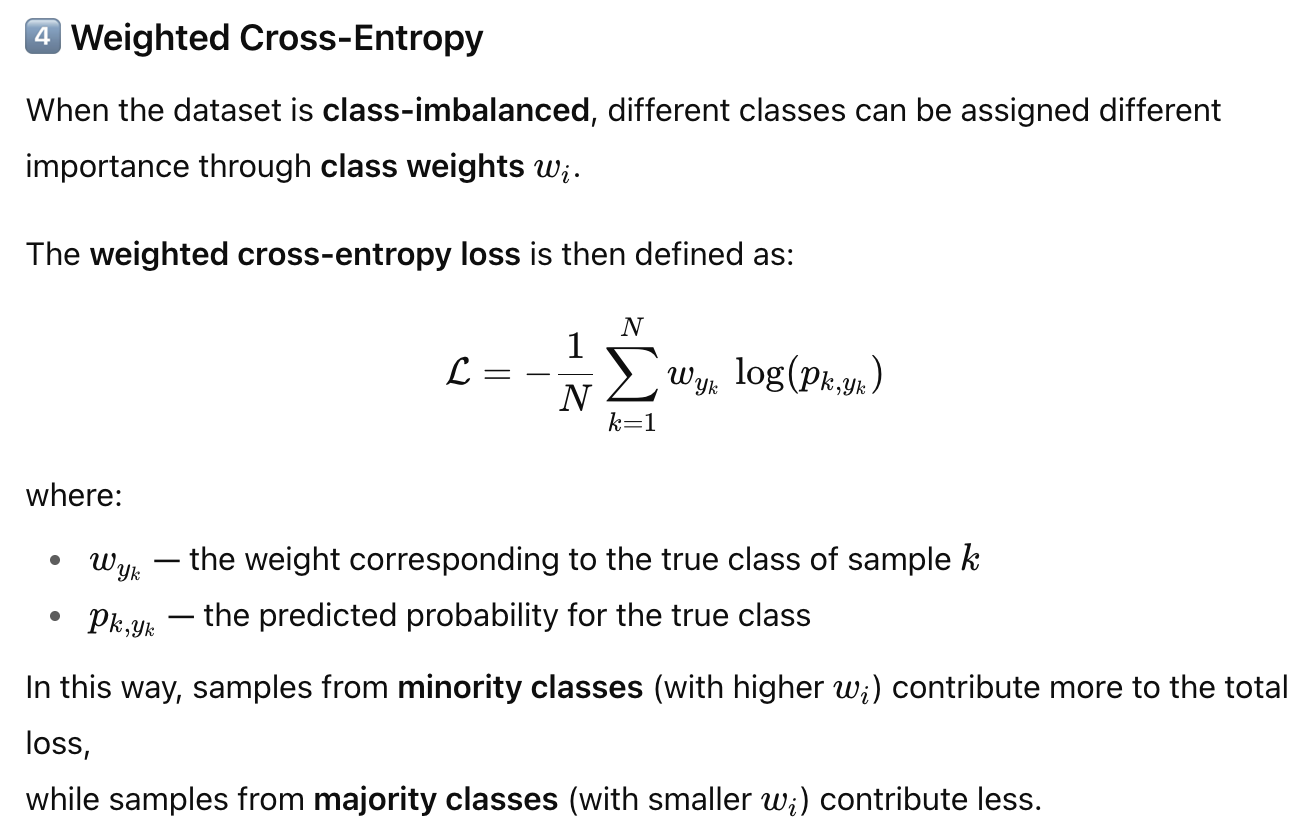



## 🧠 Step 6 — Building Our Model: ResNet50  

Now it’s time to give our project a brain 🧩 — a deep convolutional neural network that can actually *see* and *reason* about X-ray images!  

### ⚙️ What we’re doing here  
- Load a **pre-trained ResNet-50** model from ImageNet 🏋️‍♀️ — this model already knows how to recognize general visual patterns like edges and textures  
- Replace its **final fully-connected layer** (`fc`) with a new one that outputs **two classes**: `NORMAL` and `PNEUMONIA` 🩻  
- Initialize a **weighted cross-entropy loss** to handle class imbalance ⚖️  

- Set up an **Adam optimizer** and a **learning-rate scheduler** that adapts when validation performance plateaus 📉  





In [ ]:
# ===========================
# Block 3 — Model (ResNet50)
# ===========================
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.IMAGENET1K_V2
model = resnet50(weights=weights)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features,num_classes)
model = model.to(device)

# ------- stage1: Only training the last MLP layer  -------
for p in model.parameters():
    p.requires_grad = False #Freeze
for p in model.fc.parameters():
    p.requires_grad = True #Unfrezze

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 191MB/s]


## 🏋️‍♂️ Step 7 — Two-Stage Fine-Tuning Magic ✨  

It’s time to bring our model to life! 🔥  
In this section, we’ll **train our ResNet in two carefully designed stages**:

### 🎯 Stage 1 — “Warm-Up the Head”  
At first, we *freeze* the pretrained backbone 🧊 and only train the final classification layer.  
This helps the model adapt gently to our medical dataset without destroying the powerful ImageNet features it already learned.

### ⚡ Stage 2 — “Full Fine-Tuning”  
Once the head stabilizes, we *unfreeze all layers* and fine-tune the entire network end-to-end.  
This second stage lets every convolution learn the subtle radiological textures that distinguish **Pneumonia vs Normal** 🩻.

During training you’ll see:  
- **Dynamic progress bars**  ⏳  
- Real-time **loss updates**  
- Gradual **learning-rate adjustments**  📉  
- Automatic **best-model reloading** at the end 🏆  

> 💡 *Think of this as teaching the model to speak the language of X-rays — starting with simple phrases, then mastering medical nuance.*


In [ ]:
# ==================================
# Block 4 — Training (2-stage fine-tune)
# ==================================
from tqdm import tqdm

def accuracy_on_loader(m, loader):
    m.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = m(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / max(total, 1)

EPOCHS = 5
best_val_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):

    # ----- switch the stage -----
    if epoch == 2: #only the first 2 epochs train on the fully connected layer
        print("\n>>> Unfreezing all layers for full fine-tuning <<<")
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    model.train()
    running_loss, seen = 0.0, 0

    pbar = tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS} - training")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = y.size(0)
        running_loss += loss.item() * bs
        seen += bs
        pbar.set_postfix(loss=running_loss / seen if seen else 0.0)

    train_loss = running_loss / max(seen, 1)
    test_acc = accuracy_on_loader(model, test_dl)
    print(f"[Epoch {epoch}/{EPOCHS}] Train Loss: {train_loss:.4f} | Test Acc: {test_acc*100:.2f}%")

    val_acc = accuracy_on_loader(model, val_dl)
    scheduler.step(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
print(f"Training complete. Best VAL Acc: {best_val_acc*100:.2f}% (best model reloaded).")

Epoch 1/5 - training: 100%|██████████| 147/147 [01:42<00:00,  1.43it/s, loss=0.366]


[Epoch 1/5] Train Loss: 0.3664 | Test Acc: 91.31%

>>> Unfreezing all layers for full fine-tuning <<<


Epoch 2/5 - training: 100%|██████████| 147/147 [01:56<00:00,  1.26it/s, loss=0.168]


[Epoch 2/5] Train Loss: 0.1682 | Test Acc: 76.32%


Epoch 3/5 - training: 100%|██████████| 147/147 [01:54<00:00,  1.28it/s, loss=0.105]


[Epoch 3/5] Train Loss: 0.1048 | Test Acc: 95.23%


Epoch 4/5 - training: 100%|██████████| 147/147 [01:50<00:00,  1.33it/s, loss=0.0704]


[Epoch 4/5] Train Loss: 0.0704 | Test Acc: 95.23%


Epoch 5/5 - training: 100%|██████████| 147/147 [01:49<00:00,  1.35it/s, loss=0.0569]


[Epoch 5/5] Train Loss: 0.0569 | Test Acc: 94.89%
Training complete. Best VAL Acc: 97.09% (best model reloaded).


## 🔎 Step 8 — Validate Like a Pro: Metrics that Matter

Time to **measure what we’ve actually learned** — on data the model hasn’t seen during training.  
In this block, we’ll evaluate performance on the **validation set (VAL)** to guide model tuning and catch overfitting early.

### 📊 What happens here
- Switch the model to **evaluation mode** (`model.eval()`), disable gradients, and loop through `val_dl` ⏳  
- Collect **logits, predicted labels, and ground-truth labels** for the entire split  
- Compute a detailed **Classification Report** (precision, recall, F1 for each class)  
- Build a **Confusion Matrix** to see where the model confuses NORMAL vs PNEUMONIA 🧩  
- Use calibrated **probabilities** (via `softmax`) to calculate:
  - **ROC-AUC** — ranking ability across thresholds 📈  
  - **PR-AUC** (Average Precision) — especially informative under **class imbalance** ⚖️

### 🧠 Why it matters
Validation metrics are your **early warning system**: they show whether training is helping or just overfitting.  
Using AUC scores alongside accuracy gives a **threshold-independent** view — crucial in medical screening where **false negatives** are costly.

> 💡 *Tip:* If PR-AUC lags behind ROC-AUC, your positives are rare — consider better class balancing, focal loss, or threshold tuning.


In [ ]:
# =================
# Block 5 — Eval on VAL
# =================
import torch.nn.functional as F
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

idx_to_class = {v: k for k, v in train_ds.class_to_idx.items()}
print("Class mapping:", idx_to_class)

model.eval()
all_logits, all_preds, all_labels = [], [], []
with torch.no_grad():
    for x, y in tqdm(val_dl, desc="Evaluating on VAL"):
        x = x.to(device)
        logits = model(x)
        all_logits.append(logits.cpu())
        all_preds.append(logits.argmax(1).cpu().numpy())
        all_labels.append(y.numpy())

all_logits = torch.cat(all_logits, dim=0)
all_preds  = np.concatenate(all_preds, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

pos_idx = train_ds.class_to_idx.get("PNEUMONIA", 1)
probs = F.softmax(all_logits, dim=1)[:, pos_idx].numpy()

print("\n=== Classification Report (VAL) ===")
print(classification_report(all_labels, all_preds,
                            target_names=[idx_to_class[i] for i in range(num_classes)],
                            digits=4))

cm = confusion_matrix(all_labels, all_preds)
print("Confusion Matrix (VAL):\n", cm)

try:
    roc_auc = roc_auc_score(all_labels, probs)
    print(f"ROC-AUC (VAL): {roc_auc:.4f}")
except Exception as e:
    print("ROC-AUC could not be computed:", e)

try:
    ap = average_precision_score(all_labels, probs)
    print(f"PR-AUC (VAL): {ap:.4f}")
except Exception as e:
    print("PR-AUC could not be computed:", e)


Class mapping: {0: 'NORMAL', 1: 'PNEUMONIA'}


Evaluating on VAL: 100%|██████████| 19/19 [00:13<00:00,  1.39it/s]


=== Classification Report (VAL) ===
              precision    recall  f1-score   support

      NORMAL     0.9548    0.9367    0.9457       158
   PNEUMONIA     0.9767    0.9836    0.9802       427

    accuracy                         0.9709       585
   macro avg     0.9658    0.9602    0.9629       585
weighted avg     0.9708    0.9709    0.9709       585

Confusion Matrix (VAL):
 [[148  10]
 [  7 420]]
ROC-AUC (VAL): 0.9928
PR-AUC (VAL): 0.9968


## 🧪 Comparison Study — With vs. Without Pretraining  

Let’s compare two worlds 🌍 — the same ResNet50 trained **with ImageNet weights** vs. **from scratch** (no pretraining).  
Everything else stays identical: data, transforms, optimizer, and epochs.

### ⚖️ Why this matters  
This test shows how **transfer learning** speeds up convergence and boosts accuracy, especially when data is limited.


> 💡 *Hint:* If the pretrained model learns faster and performs better — that’s the power of transfer learning in action!


In [ ]:
# =================
# Block 6 - Compare with train with scratch
# =================

from torchvision.models import resnet50

model = resnet50(weights=None)

in_features = model.fc.in_features
model.fc = nn.Linear(in_features, num_classes)
model = model.to(device)


for p in model.parameters():
    p.requires_grad = False
for p in model.fc.parameters():
    p.requires_grad = True

criterion = nn.CrossEntropyLoss(weight=class_weights)


optimizer = optim.Adam(model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)


from tqdm import tqdm

def accuracy_on_loader(m, loader):
    m.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = m(x).argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / max(total, 1)

EPOCHS = 5
best_val_acc, best_state = 0.0, None

for epoch in range(1, EPOCHS + 1):

    if epoch == 2:
        print("\n>>> Unfreezing all layers for full fine-tuning <<<")
        for p in model.parameters():
            p.requires_grad = True
        optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=1)

    model.train()
    running_loss, seen = 0.0, 0

    pbar = tqdm(train_dl, desc=f"Epoch {epoch}/{EPOCHS} - training")
    for x, y in pbar:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = y.size(0)
        running_loss += loss.item() * bs
        seen += bs
        pbar.set_postfix(loss=running_loss / seen if seen else 0.0)

    train_loss = running_loss / max(seen, 1)
    test_acc = accuracy_on_loader(model, test_dl)
    print(f"[Epoch {epoch}/{EPOCHS}] Train Loss: {train_loss:.4f} | Test Acc: {test_acc*100:.2f}%")

    val_acc = accuracy_on_loader(model, val_dl)
    scheduler.step(val_acc)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

if best_state is not None:
    model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
print(f"Training complete. Best VAL Acc: {best_val_acc*100:.2f}% (best model reloaded).")

Epoch 1/5 - training: 100%|██████████| 147/147 [01:39<00:00,  1.48it/s, loss=0.517]


[Epoch 1/5] Train Loss: 0.5171 | Test Acc: 82.96%

>>> Unfreezing all layers for full fine-tuning <<<


Epoch 2/5 - training: 100%|██████████| 147/147 [01:51<00:00,  1.32it/s, loss=0.347]


[Epoch 2/5] Train Loss: 0.3466 | Test Acc: 39.86%


Epoch 3/5 - training: 100%|██████████| 147/147 [01:56<00:00,  1.26it/s, loss=0.303]


[Epoch 3/5] Train Loss: 0.3034 | Test Acc: 49.74%


Epoch 4/5 - training: 100%|██████████| 147/147 [01:53<00:00,  1.30it/s, loss=0.286]


[Epoch 4/5] Train Loss: 0.2861 | Test Acc: 83.13%


Epoch 5/5 - training: 100%|██████████| 147/147 [01:55<00:00,  1.27it/s, loss=0.256]


[Epoch 5/5] Train Loss: 0.2556 | Test Acc: 43.95%
Training complete. Best VAL Acc: 85.64% (best model reloaded).
